# External heat sources

There are several circumstances in which a circuit can be influenced by external heat sources that cannot be modelled by the cable thermal model (yet). Examples of such external heat sources include
- External heat sources that are not cables, e.g., a nearby transformer for cables in air.
- Cables of a third party that can't be modelled due to absent load data.

A workaround to still estimate the cable temperature in a situation like this is by adding the expected temperature effect on the cables that are being modelled to the `ambient_temperature` column of the `scenario` DataFrame. When it is not possible to estimate the expected effect, we recommend to use a conservative estimate.

## Asphalt

On sunny days, cables that lie close to the surface beneath asphalt tend to get hotter. To deal with such situation we recommend to add the expected temperature effect to the `ambient_temperature` column of the `scenario` DataFrame. This depends of course on several parameters such as the depth the cable is buried at, the solar intensity. 

## Example

In the example below we consider one trefoil circuit in soil. We suppose that the circuit lies below a surface that absorbs rediational heat from the sun. To estimate the thermal impact on the cable, we modify the `ambient_temperature` column of the scenario, depending on the time of the day. 

> **_NOTE:_** The parameters used in the example are fictional and should not be adopted without further thought for your own use case.


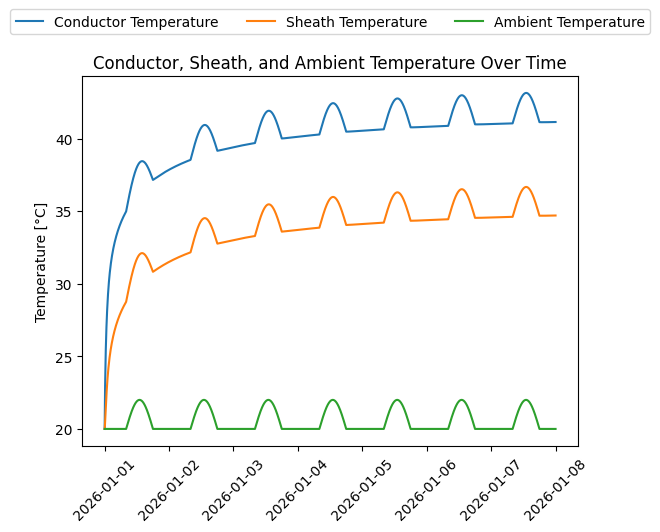

In [ ]:
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from cable_thermal_model import CableLayer, CablePosition, CircuitType, ModelFactory
from cable_thermal_model.cable.schemas.circuit_schemas import (
    CircuitInSoilFromCableIdInputSchema,
)
from cable_thermal_model.environment.static_env_soil import StaticEnvSoil

# We calculate temperatures for a week of data with a step size of 5 minutes
START_DATE = datetime(2026, 1, 1)
DAYS_TO_SIMULATE = 7
SUNRISE_HOUR = 8
SUNSET_HOUR = 18

# Environment parameters
CIRCUIT_LOAD = 575  # [A]
AMBIENT_TEMPERATURE = 20  # [°C]
SOIL_THERMAL_RESISTIVITY = 0.5  # [K·m/W]
SOIL_THERMAL_CAPACITY = 2e6  # [J/m³·K]

# We calculate temperatures for a week of data with a step size of 5 minutes
scenario = pd.DataFrame(
    index=pd.date_range(start=START_DATE, end=START_DATE + pd.Timedelta(days=DAYS_TO_SIMULATE), freq="5min")
)

# We add the environment parameters to the scenario. In this example they are all constant.
scenario["load_circuit_1"] = CIRCUIT_LOAD
scenario["ambient_temperature"] = AMBIENT_TEMPERATURE
scenario["soil_thermal_resistivity"] = SOIL_THERMAL_RESISTIVITY
scenario["soil_thermal_capacity"] = SOIL_THERMAL_CAPACITY

# In this example we use a fictive heat source,
# which we estimate to have a maximal influence of 2 K from 8 am until 6 pm every day.
# During this period, the heat source behaves like a sine wave
EXTERNAL_HEAT_SOURCE_INFLUENCE = (
    2
    * pd.Series(
        (scenario.index.hour >= SUNRISE_HOUR) & (scenario.index.hour < SUNSET_HOUR), index=scenario.index, dtype=float
    )
    * pd.Series(
        np.sin(
            np.pi
            * ((scenario.index.hour - SUNRISE_HOUR) * 60 + scenario.index.minute)
            / ((SUNSET_HOUR - SUNRISE_HOUR) * 60)
        ),
        index=scenario.index,
    )
)

scenario["ambient_temperature"] += EXTERNAL_HEAT_SOURCE_INFLUENCE

# In this example we create a static environment consisting of a single circuit in soil.
static_env = StaticEnvSoil()
static_env.add_circuit_from_cable_id(
    CircuitInSoilFromCableIdInputSchema(
        x=0.0,
        y=-0.5,
        circuit_name="circuit_1",
        circuit_type=CircuitType.Trefoil,
        cable_id="YMeKrvaslqwd 12/20kV 1x630 Alrm + as50",
        cable_source_file_path=Path("../../data/example_cables.csv"),
    )
)

# We calculate the temperatures for the scenario
model = ModelFactory.create_model(static_env, scenario)
solution = model.run()

# Plot the temperature results for the conductor and the sheath of the top cable in the circuit
plt.plot(
    scenario.index,
    solution.result["circuit_1"][CablePosition.TrefoilTop][CableLayer.Conductor],
    label="Conductor Temperature",
)
plt.plot(
    scenario.index,
    solution.result["circuit_1"][CablePosition.TrefoilTop][CableLayer.Sheath],
    label="Sheath Temperature",
)
plt.plot(scenario.index, scenario["ambient_temperature"], label="Ambient Temperature")
plt.ylabel("Temperature [°C]")
plt.title("Conductor, Sheath, and Ambient Temperature over Time")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.2), ncol=3)
plt.xticks(rotation=45)
plt.show()